# Diffusion Models from Scratch — Demo

This notebook demonstrates the modular implementation of DDPM and DDIM in this repository.

The core implementations are located in:

- `models/` — timestep-conditioned noise prediction network
- `diffusion/` — diffusion process and DDPM/DDIM sampling
- `utils/` — training and visualization utilities

The notebook focuses on experimentation and visualization rather than duplicating the model implementation.

In [42]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# Locate project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.unet import BasicDiscreteTimeModel
from diffusion.ddim import DDIM
from utils.trainer import train

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ASUS\Desktop\diffusion-models-from-scratch


In [43]:
# =========================
# Configuration
# =========================

seed = 42

n_steps = 100
d_model = 128
n_layers = 2

batch_size = 128
n_epochs = 400
n_samples = 512


# =========================
# Reproducibility
# =========================

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


# =========================
# Device
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


Dataset shape: (1024, 2)


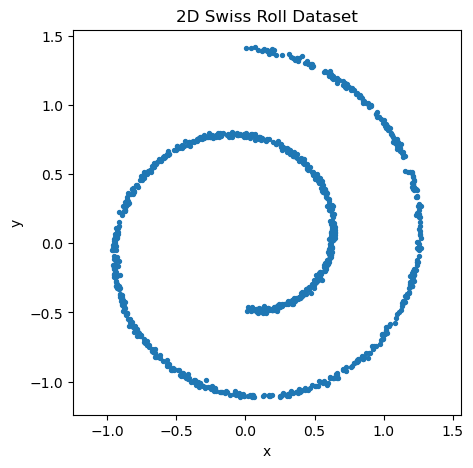

In [44]:
from sklearn.datasets import make_swiss_roll

N = 1024

X = make_swiss_roll(
    n_samples=N,
    noise=1e-1,
    random_state=seed,
)[0][:, [0, 2]] / 10.0

print("Dataset shape:", X.shape)

plt.figure(figsize=(5, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    s=8,
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Swiss Roll Dataset")
plt.axis("equal")
plt.show()

In [45]:
# =========================
# Model
# =========================

model = BasicDiscreteTimeModel(
    d_model=d_model,
    n_layers=n_layers,
).to(device)


# =========================
# Diffusion Process
# =========================

diffuser = DDIM(
    n_steps=n_steps,
).to(device)


print(model)
print("\nModel device:", next(model.parameters()).device)
print("Diffusion device:", diffuser.beta.device)

BasicDiscreteTimeModel(
  (lin_in): Linear(in_features=2, out_features=128, bias=True)
  (lin_out): Linear(in_features=128, out_features=2, bias=True)
  (blocks): ParameterList(
      (0): Object of type: DiscreteTimeResidualBlock
      (1): Object of type: DiscreteTimeResidualBlock
    (0): DiscreteTimeResidualBlock(
      (emb): PositionalEncoding()
      (lin1): Linear(in_features=128, out_features=128, bias=True)
      (lin2): Linear(in_features=128, out_features=128, bias=True)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (act): GELU(approximate='none')
    )
    (1): DiscreteTimeResidualBlock(
      (emb): PositionalEncoding()
      (lin1): Linear(in_features=128, out_features=128, bias=True)
      (lin2): Linear(in_features=128, out_features=128, bias=True)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (act): GELU(approximate='none')
    )
  )
)

Model device: cuda:0
Diffusion device: cuda:0


In [46]:
# =========================
# Training
# =========================

losses = train(
    model=model,
    diffuser=diffuser,
    batch_size=batch_size,
    n_epochs=n_epochs,
    seed=seed,
)

print("\nTraining finished.")
print("Number of recorded epochs:", len(losses))
print("Final loss:", losses[-1])

Training on device: cuda:0


Epoch 400/400 | Loss 0.6704: 100%|██████████| 400/400 [00:09<00:00, 41.11it/s]


Training finished.
Number of recorded epochs: 400
Final loss: 0.6704164892435074


Loss shape: (400,)
Initial loss: 0.999222531914711
Final loss: 0.6704164892435074


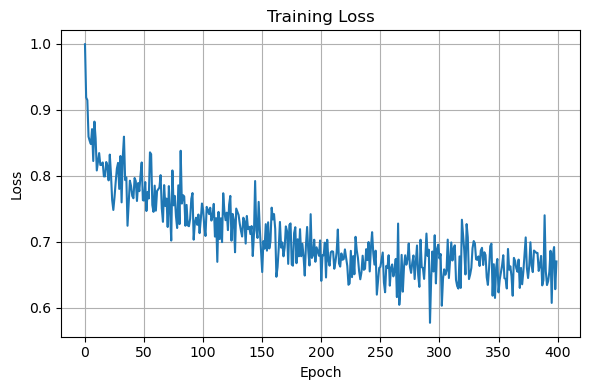

In [47]:
# =========================
# Training Loss
# =========================

loss_array = np.asarray(losses)

print("Loss shape:", loss_array.shape)
print("Initial loss:", loss_array[0])
print("Final loss:", loss_array[-1])

plt.figure(figsize=(6, 4))
plt.plot(loss_array)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

DDPM sample shape: (512, 2)


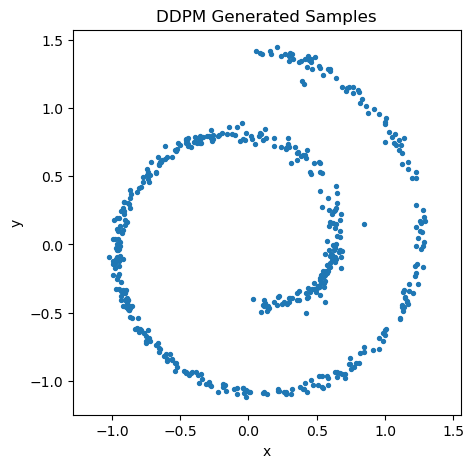

In [48]:
# =========================
# DDPM Sampling
# =========================

ddpm_samples = diffuser.ddpm_sample(
    model,
    n_samples=n_samples,
)

ddpm_samples = ddpm_samples.detach().cpu().numpy()

print("DDPM sample shape:", ddpm_samples.shape)

plt.figure(figsize=(5, 5))
plt.scatter(
    ddpm_samples[:, 0],
    ddpm_samples[:, 1],
    s=8,
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("DDPM Generated Samples")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axis("equal")
plt.show()

DDIM sample shape: (512, 2)


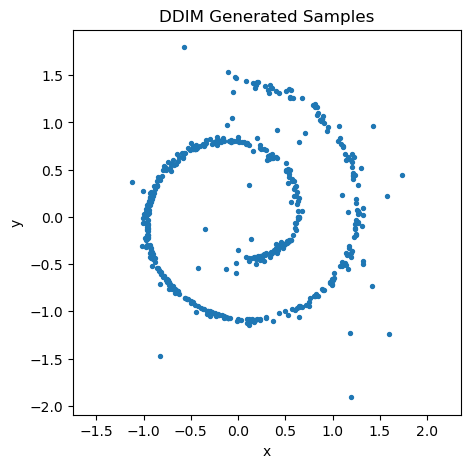

In [49]:
# =========================
# DDIM Sampling
# =========================

ddim_samples = diffuser.ddim_sample(
    model,
    n_samples=n_samples,
)

ddim_samples = ddim_samples.detach().cpu().numpy()

print("DDIM sample shape:", ddim_samples.shape)

plt.figure(figsize=(5, 5))
plt.scatter(
    ddim_samples[:, 0],
    ddim_samples[:, 1],
    s=8,
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("DDIM Generated Samples")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axis("equal")
plt.show()

In [50]:
# =========================
# Reverse Diffusion Trajectories
# =========================

ddpm_trajectory = diffuser.ddpm_sample(
    model,
    n_samples=n_samples,
    return_trajectory=True,
)

ddim_trajectory = diffuser.ddim_sample(
    model,
    n_samples=n_samples,
    return_trajectory=True,
)

print("DDPM trajectory states:", len(ddpm_trajectory))
print("DDIM trajectory states:", len(ddim_trajectory))

DDPM trajectory states: 101
DDIM trajectory states: 20


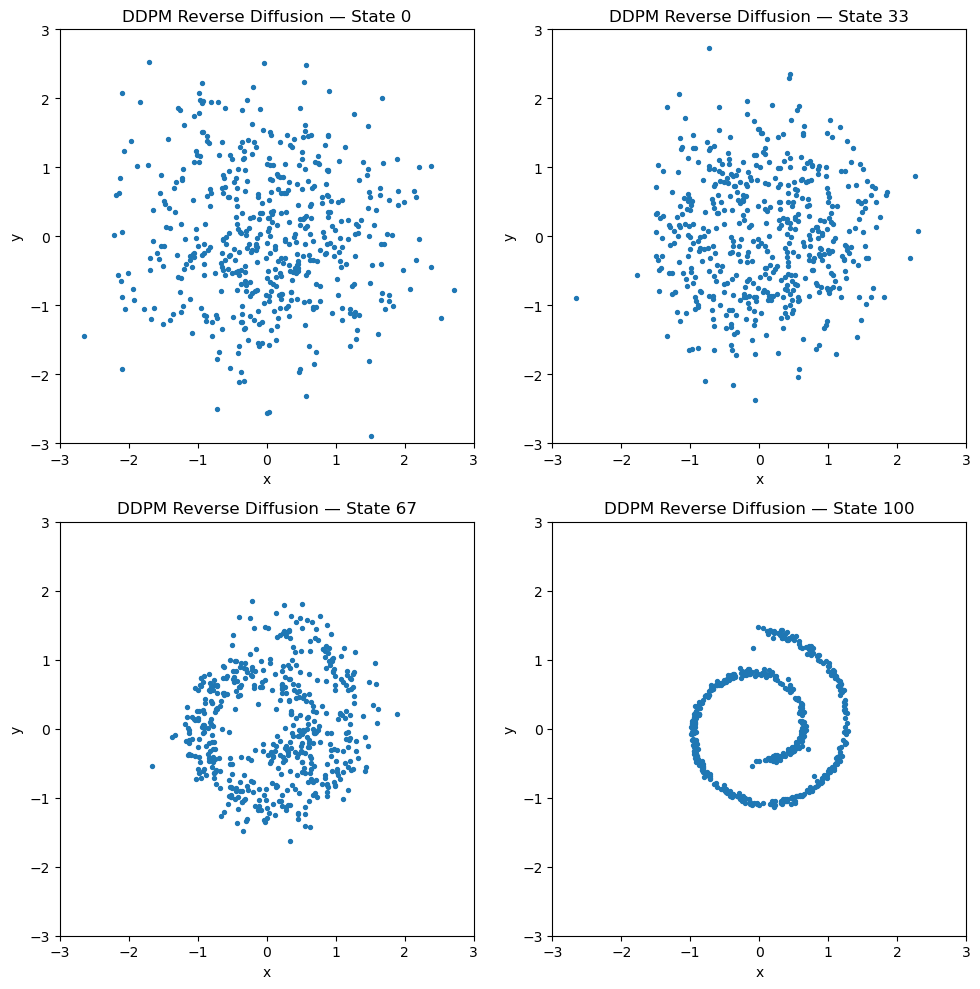

In [51]:
# =========================
# DDPM Reverse Diffusion Visualization
# =========================

indices = [
    0,
    len(ddpm_trajectory) // 3,
    2 * len(ddpm_trajectory) // 3,
    len(ddpm_trajectory) - 1,
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    samples = ddpm_trajectory[idx].numpy()

    ax.scatter(
        samples[:, 0],
        samples[:, 1],
        s=8,
    )

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"DDPM Reverse Diffusion — State {idx}")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

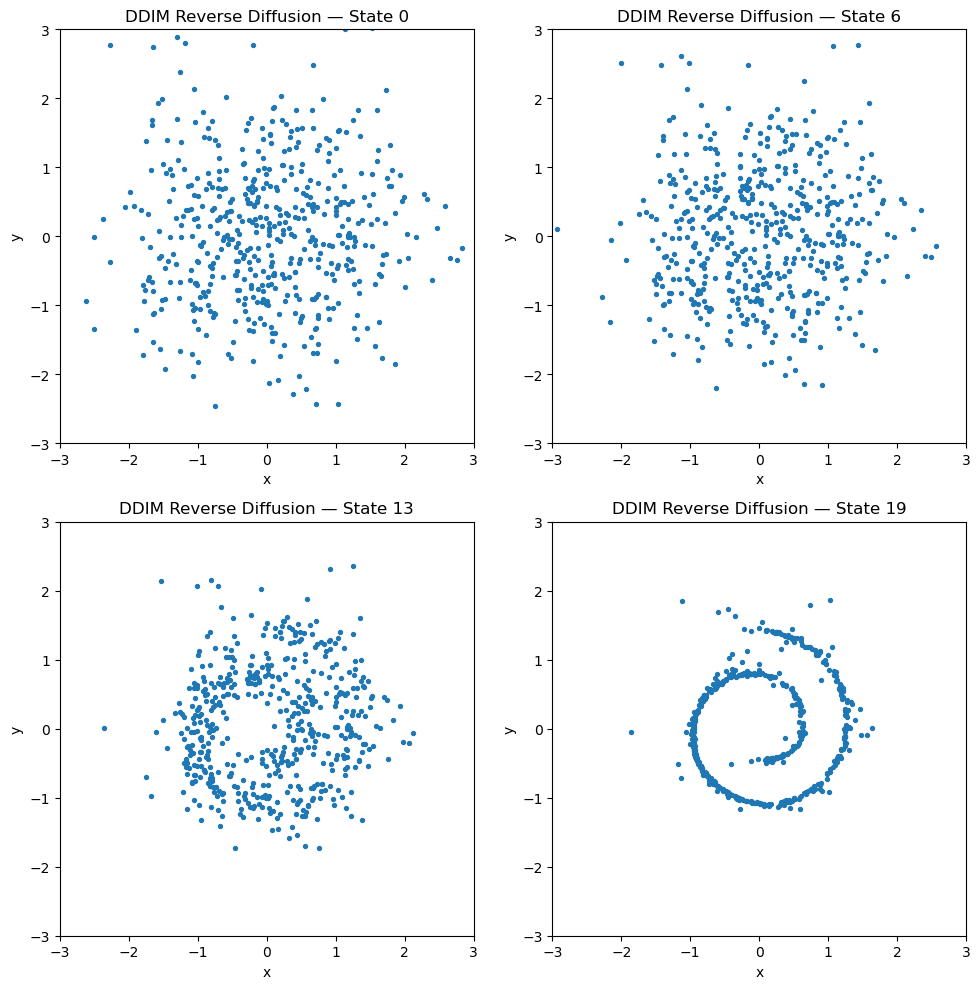

In [52]:
# =========================
# DDIM Reverse Diffusion Visualization
# =========================

indices = [
    0,
    len(ddim_trajectory) // 3,
    2 * len(ddim_trajectory) // 3,
    len(ddim_trajectory) - 1,
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    samples = ddim_trajectory[idx].numpy()

    ax.scatter(
        samples[:, 0],
        samples[:, 1],
        s=8,
    )

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"DDIM Reverse Diffusion — State {idx}")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

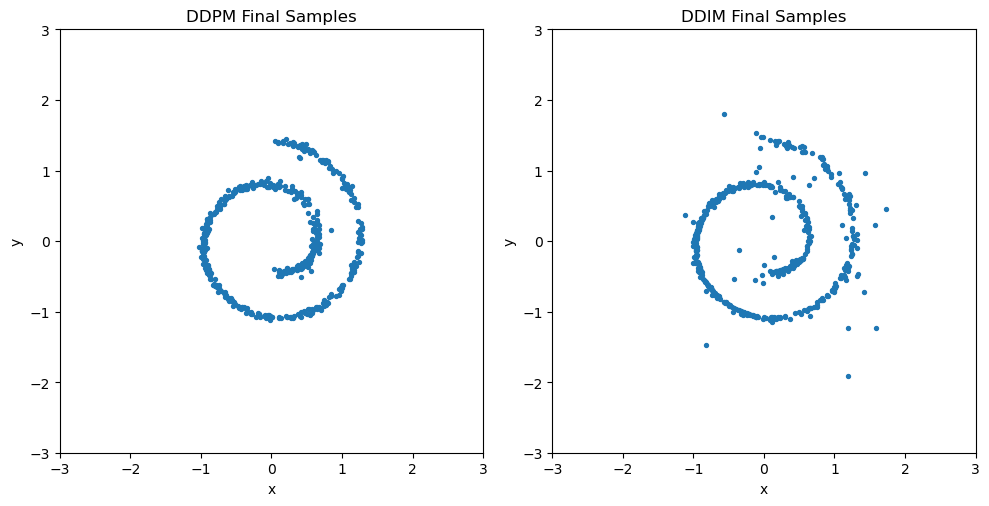

In [53]:
# =========================
# Final Sample Comparison
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(
    ddpm_samples[:, 0],
    ddpm_samples[:, 1],
    s=8,
)
axes[0].set_title("DDPM Final Samples")
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

axes[1].scatter(
    ddim_samples[:, 0],
    ddim_samples[:, 1],
    s=8,
)
axes[1].set_title("DDIM Final Samples")
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates a modular implementation of diffusion models on a 2D Swiss Roll dataset.

The main components include:

- A timestep-conditioned noise prediction network
- Forward diffusion with a linear beta schedule
- DDPM reverse sampling
- DDIM deterministic sampling
- CUDA-enabled training and sampling
- Visualization of the reverse diffusion trajectories

Both DDPM and DDIM use the same trained noise prediction model but differ in their reverse sampling procedures.

In the current configuration:

- **DDPM** uses 100 reverse diffusion steps and performs stochastic sampling.
- **DDIM** uses at most 20 selected timesteps and performs deterministic sampling with `eta = 0`.

The experiments show that both samplers can recover the underlying 2D data distribution, while DDIM requires substantially fewer reverse sampling steps.

The maintained implementations used in this notebook are located in the project source modules:

- `models/`
- `diffusion/`
- `utils/`

For standalone training and inference, use:

```bash
python train.py
python sample.py
```